In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_excel("../Dataset/Membership.xlsx")
df.shape # (18183, 15)

(18183, 15)

In [4]:
df.columns

Index(['user_no', 'product_cd', 'amount', 'billing_method',
       'concurrent_streams', 'promotion_yn', 'is_churn_prevented',
       'repurchase', 'payment_device', 'is_user_verified', 'gender', 'age',
       'reg_date', 'reg_hour', 'end_date'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18183 entries, 0 to 18182
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   user_no             18183 non-null  object        
 1   product_cd          18183 non-null  object        
 2   amount              18183 non-null  float64       
 3   billing_method      18183 non-null  int64         
 4   concurrent_streams  18113 non-null  float64       
 5   promotion_yn        9203 non-null   object        
 6   is_churn_prevented  3257 non-null   object        
 7   repurchase          11931 non-null  object        
 8   payment_device      18183 non-null  object        
 9   is_user_verified    17583 non-null  object        
 10  gender              18019 non-null  object        
 11  age                 18019 non-null  float64       
 12  reg_date            18183 non-null  datetime64[ns]
 13  reg_hour            18183 non-null  int64     

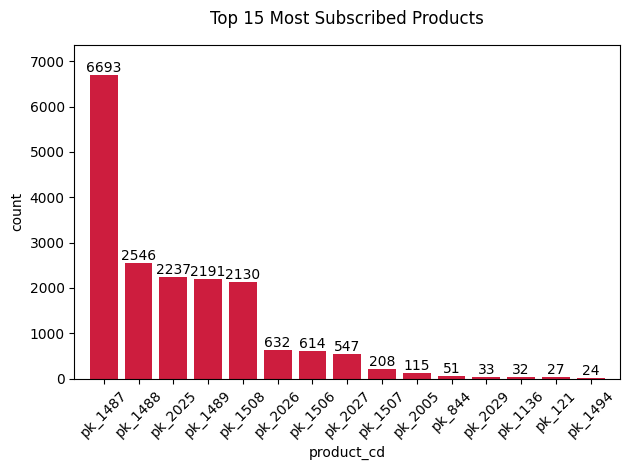

In [6]:
ax = sns.barplot(df['product_cd'].value_counts().head(15), color=(234/255, 0/255, 44/255))
plt.xticks(rotation=45)
plt.title("Top 15 Most Subscribed Products", pad = 15)
plt.margins(x=0.03, y=0.1)
plt.tight_layout()
for container in ax.containers:
	ax.bar_label(container)

> amount 컬럼의 전처리 필요성  

amount는 해당 구독제 상품의 가격을 뜻함.  
헌데, 원화와 달러화가 섞여있음.  
가령 9.99와 14900이 함께 있는데, 원화와 달러화가 같이 혼재되어 있는 것.  
이 경우 같은 값어치임에도 불구하고 박스플롯을 그리게 될 경우 이상치 처리가 되어버림.  
이는 amount 컬럼의 데이터 전처리가 필요하다는 대목  

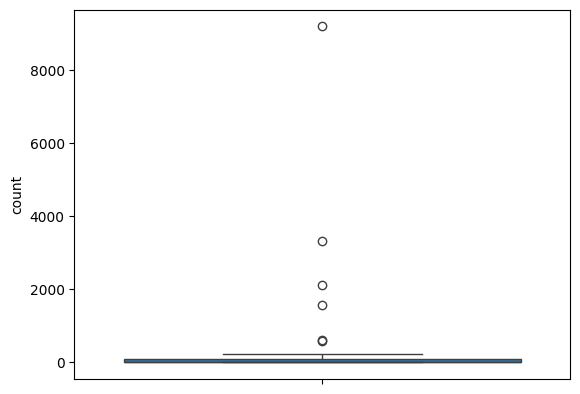

In [7]:
amount_boxplot = sns.boxplot(df["amount"].value_counts())

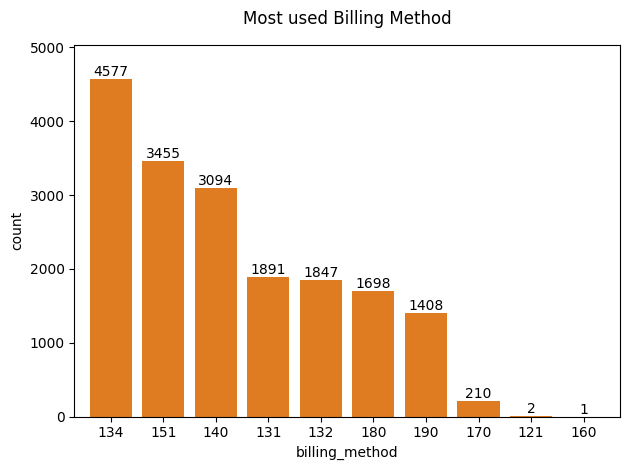

In [8]:
bill_plot = sns.barplot(df["billing_method"].astype(str).value_counts().sort_values(ascending=False), color=(255/255, 122/255, 0/255))
plt.title("Most used Billing Method", pad = 15)
plt.margins(x=0.03, y=0.1)
plt.tight_layout()
for x in bill_plot.containers:
	bill_plot.bar_label(x)

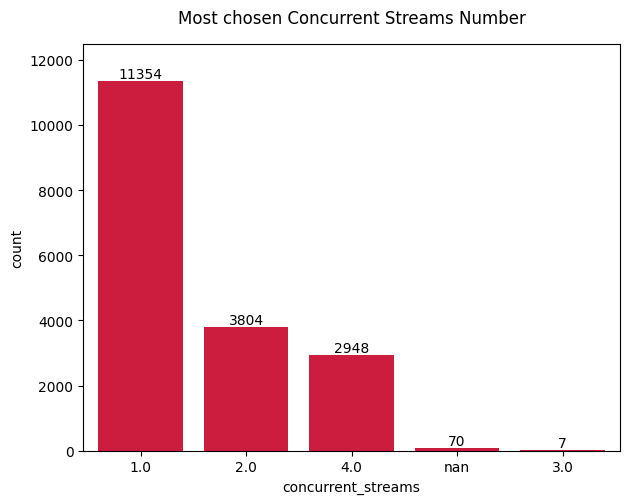

In [9]:
'''
concurrent_streams
1.0    11354
2.0     3804
4.0     2948
3.0        7
'''

concur_streams_plot = sns.barplot(df['concurrent_streams'].astype(str).value_counts(), color = (234/255, 0/255, 44/255))
plt.tight_layout()
plt.margins(x=0.03, y=0.1)
plt.title("Most chosen Concurrent Streams Number", pad = 15)
for x in concur_streams_plot.containers:
	concur_streams_plot.bar_label(x)

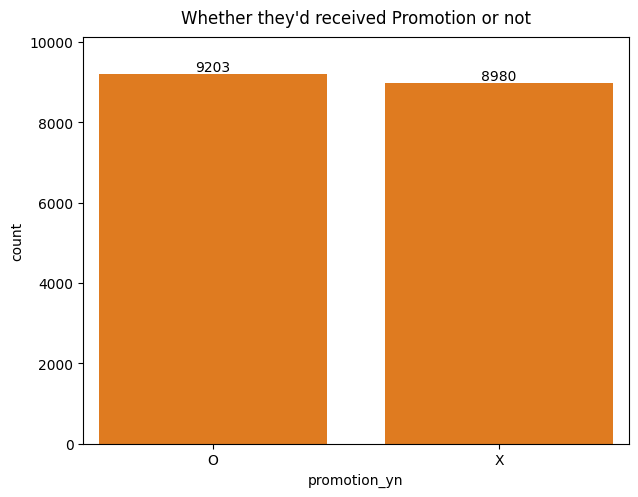

In [10]:
promotion_plot = sns.barplot(df["promotion_yn"].fillna("X").value_counts(), color=(255/255, 122/255, 0/255) )
plt.tight_layout()
plt.title("Whether they'd received Promotion or not", pad = 10)
plt.margins(x=0.03, y=0.1)
for x in promotion_plot.containers:
	promotion_plot.bar_label(x)

Text(0.5, 1.0, 'Whether CHURN had been prevented or not')

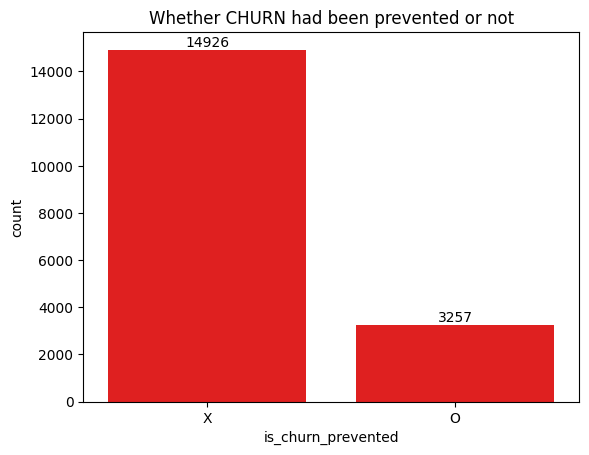

In [11]:
churn_prevent_plot = sns.barplot(df["is_churn_prevented"].fillna("X").value_counts(), color = "red")
for x in churn_prevent_plot.containers:
	churn_prevent_plot.bar_label(x)
plt.title("Whether CHURN had been prevented or not")

Text(0.5, 1.0, 'Repurchased Count')

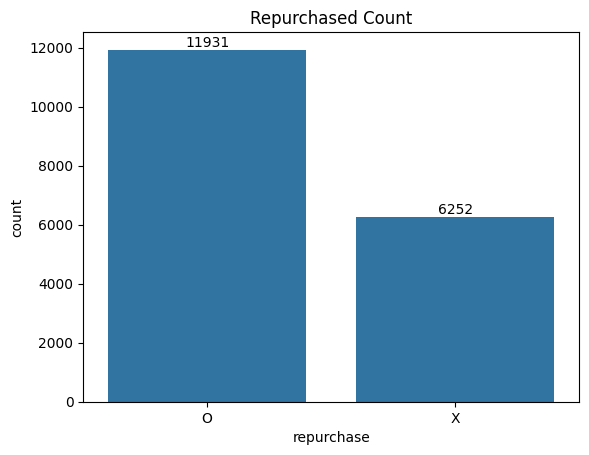

In [12]:
repurchase_plot = sns.barplot(df["repurchase"].fillna("X").value_counts())
for x in repurchase_plot.containers:
	repurchase_plot.bar_label(x)
plt.title("Repurchased Count")

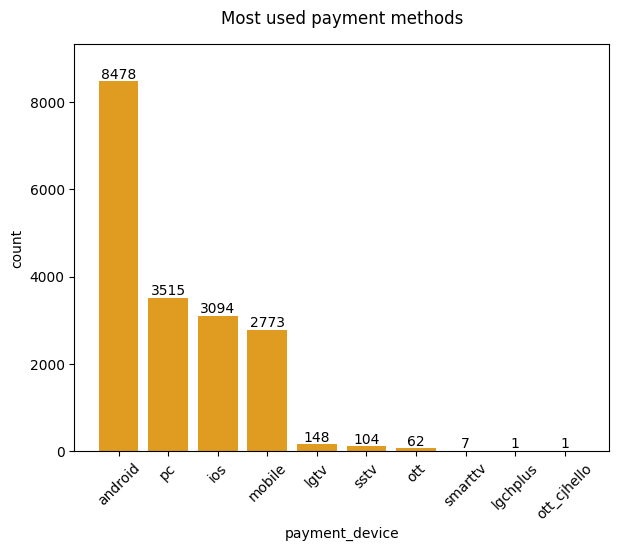

In [ ]:
payment_plot = sns.barplot(df['payment_device'].value_counts(), color = "orange")
plt.tight_layout()
plt.xticks(rotation=45)
plt.title("Most used payment methods", pad=15)
plt.margins(y=0.1, x=0.05)

for x in payment_plot.containers:
	payment_plot.bar_label(x)	

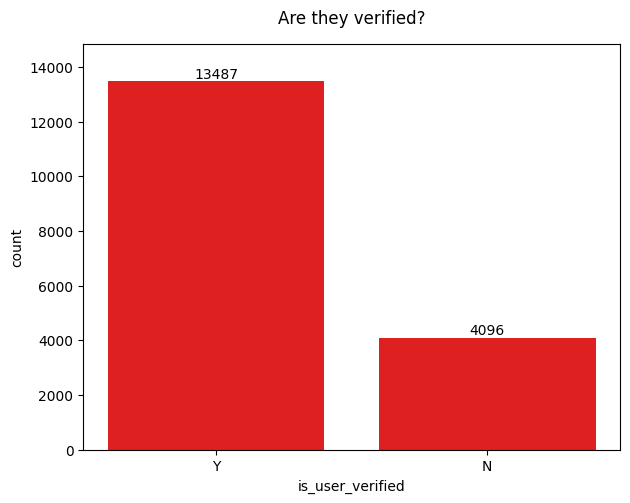

In [31]:
verify_plot = sns.barplot(df['is_user_verified'].value_counts(), color = "red")
plt.tight_layout()
plt.title("Are they verified?", pad=15)
plt.margins(y=0.1, x=0.05)

for x in verify_plot.containers:
	verify_plot.bar_label(x)	

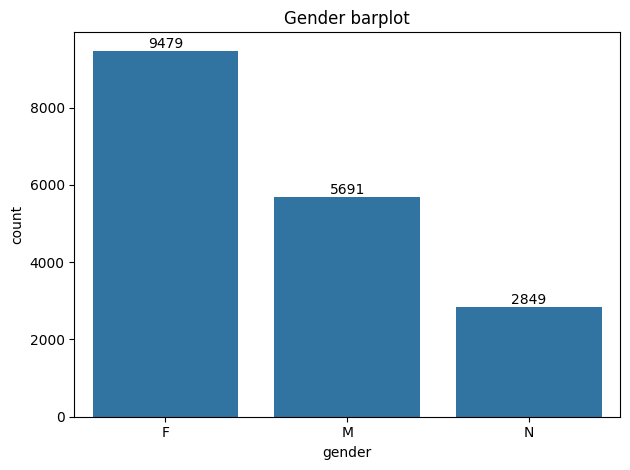

In [34]:
gender_plot = sns.barplot(df["gender"].value_counts())
plt.title("Gender barplot")
plt.tight_layout()
for x in gender_plot.containers:
	gender_plot.bar_label(x)

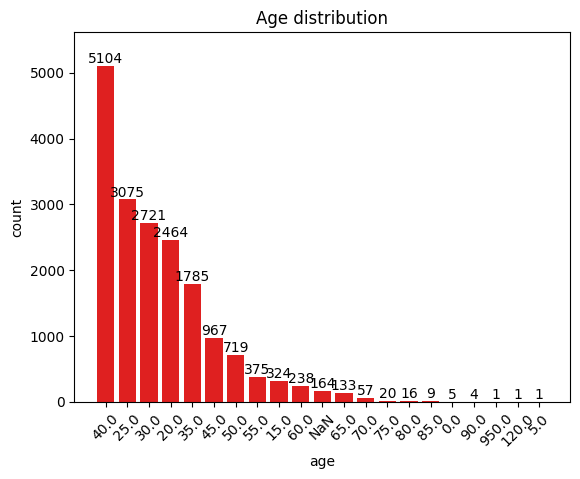

In [64]:
age_plot = sns.barplot(df["age"].fillna("NaN").value_counts(), color = "red")
plt.xticks(rotation=45)
plt.margins(x=0.05, y=0.1)
plt.title("Age distribution")
for x in age_plot.containers:
	age_plot.bar_label(x)